# Сессионный проект · Блок 2
## Основы теории вероятностей и математической статистики

**Студент:** Мирохин Юрий Валентинович · **Группа:** М26-515 · **Личный номер:** М265394

### Как работать с шаблоном

1. Сохраните личную копию и назовите её `Фамилия_Имя_Сессионный_проект_Блок_2`.
2. Заменяйте подсказки в текстовых ячейках своим решением. В кодовых ячейках размещайте вычисления и построение графиков. При необходимости добавляйте ячейки.
3. Сохраняйте номера и условия задач. Отвечайте на каждый пункт; к числовому результату добавляйте ход расчёта или пояснение.
4. Графики стройте там, где они требуются в условии. Подписывайте оси и обозначения.

Код не обязателен в заданиях, которые можно полностью решить текстом и формулами. Для текстовой задачи 4 предусмотрена таблица ответов.

### Подготовка

Запустите ячейку ниже, если будете использовать Python. Здесь подключены библиотеки для расчётов и графиков.

In [1]:
%matplotlib inline
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "font.size": 11,
})

---

## Задача 1. Две ладьи на шахматной доске

**2 балла**

На разные клетки шахматной доски случайным образом ставят белую и чёрную ладьи. Все допустимые размещения равновероятны. Найдите вероятность того, что ладьи не атакуют друг друга, то есть находятся в разных строках и разных столбцах.

### Решение

**Модель.** На доске $8\times 8 = 64$ клетки. Ставим две различимые ладьи (белую и чёрную) на разные клетки; все размещения равновероятны — применимо классическое определение вероятности.

**Всего исходов.** Белую ладью можно поставить на любую из 64 клеток, чёрную — на любую из оставшихся 63:
$$N = 64\cdot 63.$$

**Благоприятные исходы.** Ладьи не атакуют друг друга, если стоят в разных строках и разных столбцах. Поставим белую ладью на любую клетку. Она контролирует всю свою строку (ещё 7 клеток) и весь свой столбец (ещё 7 клеток) — 14 «запрещённых» клеток. Значит, для чёрной ладьи подходит
$$63 - 14 = 49$$
клеток. Благоприятных исходов:
$$M = 64\cdot 49.$$

**Вероятность.**
$$P = \frac{M}{N} = \frac{64\cdot 49}{64\cdot 63} = \frac{49}{63} = \frac{7}{9}\approx 0{,}778.$$

In [2]:
# Классическое определение вероятности
total = 64 * 63       # все размещения двух различимых ладей на разных клетках
favorable = 64 * 49   # для каждой клетки белой ладьи 49 «безопасных» клеток для чёрной
p = favorable / total
print(f"P(не атакуют) = {favorable}/{total} = 49/63 = 7/9 ≈ {p:.4f}")

P(не атакуют) = 3136/4032 = 49/63 = 7/9 ≈ 0.7778


### Ответ и пояснения

**Ответ:** $P = \dfrac{7}{9} \approx 0{,}778.$

Каждая ладья контролирует свою строку и свой столбец. После постановки белой ладьи из 63 свободных клеток 14 лежат на одной с ней линии, поэтому «безопасны» ровно 49 клеток, что и даёт $\dfrac{49}{63} = \dfrac{7}{9}$.

---

## Задача 2. Отказы сервера

**2 балла**

Вероятность отказа сервера при каждом запросе равна 0,05. Результаты обработки разных запросов независимы.

1. Найдите вероятность успешной обработки одного запроса.
2. Найдите вероятность отказа при двух последовательных запросах.
3. Найдите вероятность успешной обработки всех 20 запросов.
4. Найдите вероятность хотя бы одного отказа среди 10 запросов.

### Решение

Обозначим вероятность отказа при одном запросе $q = 0{,}05$, тогда вероятность успеха $p = 1 - q = 0{,}95$. Запросы независимы, поэтому вероятности перемножаются.

1. Успех одного запроса: $p = 1 - q = 0{,}95$.
2. Отказ при двух запросах подряд (оба отказали): $q^2 = 0{,}05^2 = 0{,}0025$.
3. Успех всех 20 запросов: $p^{20} = 0{,}95^{20}$.
4. Хотя бы один отказ среди 10 — событие, противоположное «все 10 успешны»: $1 - p^{10} = 1 - 0{,}95^{10}$.

In [3]:
q = 0.05          # вероятность отказа одного запроса
p = 1 - q         # вероятность успеха

p1 = p
p2 = q**2
p3 = p**20
p4 = 1 - p**10

print(f"1) успех одного запроса:            {p1:.4f}")
print(f"2) отказ при двух запросах подряд:  {p2:.4f}")
print(f"3) успех всех 20 запросов:          {p3:.4f}")
print(f"4) хотя бы один отказ среди 10:      {p4:.4f}")

1) успех одного запроса:            0.9500
2) отказ при двух запросах подряд:  0.0025
3) успех всех 20 запросов:          0.3585
4) хотя бы один отказ среди 10:      0.4013


### Ответ и пояснения

1. Успешная обработка одного запроса: $p = 1 - 0{,}05 = 0{,}95$.
2. Отказ при двух последовательных запросах: $0{,}05^2 = 0{,}0025$.
3. Успешная обработка всех 20 запросов: $0{,}95^{20} \approx 0{,}3585$.
4. Хотя бы один отказ среди 10 запросов: $1 - 0{,}95^{10} \approx 0{,}4013$.

---

## Задача 3. Две формулы выборочной дисперсии

**2 балла**

Дана выборка: 4, 6, 8, 10, 12.

1. Вычислите дисперсию с делением суммы квадратов отклонений на n.
2. Вычислите исправленную выборочную дисперсию с делением на $n-1$.
3. Объясните, чем различается назначение этих величин.

### Решение

Выборка: $4, 6, 8, 10, 12$, объём $n = 5$.

Среднее:
$$\bar x = \frac{4+6+8+10+12}{5} = \frac{40}{5} = 8.$$

Отклонения от среднего: $-4, -2, 0, 2, 4$; сумма их квадратов
$$\sum_{i=1}^{n} (x_i-\bar x)^2 = 16+4+0+4+16 = 40.$$

1. Дисперсия с делением на $n$:
$$D = \frac{1}{n}\sum (x_i-\bar x)^2 = \frac{40}{5} = 8.$$

2. Исправленная выборочная дисперсия (деление на $n-1$):
$$s^2 = \frac{1}{n-1}\sum (x_i-\bar x)^2 = \frac{40}{4} = 10.$$

In [4]:
import numpy as np
x = np.array([4, 6, 8, 10, 12])

D  = x.var(ddof=0)   # деление на n
s2 = x.var(ddof=1)   # деление на n-1

print(f"среднее:                          {x.mean():.1f}")
print(f"сумма квадратов отклонений:       {((x - x.mean())**2).sum():.1f}")
print(f"дисперсия (÷n):                    {D:.1f}")
print(f"исправленная дисперсия (÷(n-1)):   {s2:.1f}")

среднее:                          8.0
сумма квадратов отклонений:       40.0
дисперсия (÷n):                    8.0
исправленная дисперсия (÷(n-1)):   10.0


### Ответ и пояснения

1. Дисперсия с делением на $n$: $D = 40/5 = 8$.
2. Исправленная выборочная дисперсия: $s^2 = 40/4 = 10$.
3. Различие в назначении: деление на $n$ даёт разброс *самой выборки* (средний квадрат отклонений от выборочного среднего). Но как оценка дисперсии генеральной совокупности эта величина смещена вниз, потому что отклонения берутся от среднего, оценённого по той же выборке. Деление на $n-1$ (число степеней свободы) убирает смещение: $s^2$ — несмещённая оценка генеральной дисперсии $\sigma^2$. Итог: $D$ описывает имеющиеся данные, $s^2$ применяют для статистического вывода о генеральной совокупности.

---

## Задача 4. Аудит утверждений о PDF и CDF

**3 балла**

Для каждого утверждения укажите, верно оно или нет, и дайте короткое объяснение.

1. Случайная величина может принимать только положительные значения.
2. Плотность вероятности может принимать значения больше 1.
3. Функция распределения любой случайной величины непрерывна.
4. Плотность экспоненциального распределения равна нулю при $x<0$.
5. Интеграл плотности по всей числовой прямой может отличаться от 1.
6. Функция распределения всегда строго возрастает.
7. Для непрерывной случайной величины $P(X=x)=0$.
8. Функция распределения дискретной случайной величины имеет ступенчатый вид.
9. Для дискретной случайной величины отдельные значения описываются функцией вероятностей, а не плотностью.
10. Значение плотности $p(x)$ равно вероятности события $X=x$.

### Ваши ответы

Заполните обе колонки для каждого утверждения.

| № | Верно / неверно | Короткое объяснение |
|:--:|:--|:--|
| 1 | неверно | В общем случае случайная величина принимает любые действительные значения, в том числе отрицательные и ноль (например, нормальная). Положительность — свойство лишь отдельных распределений. |
| 2 | верно | Плотность не является вероятностью и может быть больше 1; требуется только, чтобы её интеграл равнялся 1 (напр., равномерное на $[0;0{,}5]$ имеет $p(x)=2$). |
| 3 | неверно | Непрерывна функция распределения только у непрерывных случайных величин; у дискретных она ступенчатая (со скачками). В общем случае $F(x)$ лишь непрерывна справа. |
| 4 | верно | Экспоненциальное распределение задано на $[0;\infty)$, поэтому при $x<0$ плотность равна 0. |
| 5 | неверно | Условие нормировки требует $\int_{-\infty}^{+\infty} p(x)\,dx = 1$ всегда. |
| 6 | неверно | $F(x)$ не убывает (монотонно неубывающая), но может быть постоянной там, где плотность равна 0; строгого возрастания нет. |
| 7 | верно | Для непрерывной случайной величины вероятность попасть в отдельную точку равна нулю: $P(X=x)=0$. |
| 8 | верно | У дискретной случайной величины $F(x)$ — ступенчатая функция; величина скачка в точке равна вероятности соответствующего значения. |
| 9 | верно | Дискретная случайная величина описывается функцией (законом) вероятностей $P(X=x_i)=p_i$; плотности у неё нет. |
| 10 | неверно | $p(x)$ — это плотность, а не вероятность; для непрерывной величины $P(X=x)=0$. Вероятность получается интегрированием плотности по промежутку. |

---

## Задача 5. Функция распределения Бернулли

**2 балла**

Случайная величина X равна 1 при успехе и 0 при неудаче. Вероятность успеха $P(X=1)=0{,}6$. Запишите функцию распределения в принятой в курсе форме $F_X(x)=P(X<x)$. Постройте её график.

### Решение

Случайная величина Бернулли: $P(X=1)=0{,}6$, $P(X=0)=0{,}4$.

В курсе принято определение $F_X(x)=P(X<x)$ (строгое неравенство), поэтому функция непрерывна слева, а скачки происходят сразу после точек 0 и 1.

- при $x\le 0$ событий $X<x$ нет $\Rightarrow F(x)=0$;
- при $0<x\le 1$ подходит только значение $X=0 \Rightarrow F(x)=P(X=0)=0{,}4$;
- при $x>1$ подходят оба значения $\Rightarrow F(x)=P(X=0)+P(X=1)=1$.

$$F_X(x)=\begin{cases}0, & x\le 0,\\[2pt] 0{,}4, & 0<x\le 1,\\[2pt] 1, & x>1.\end{cases}$$

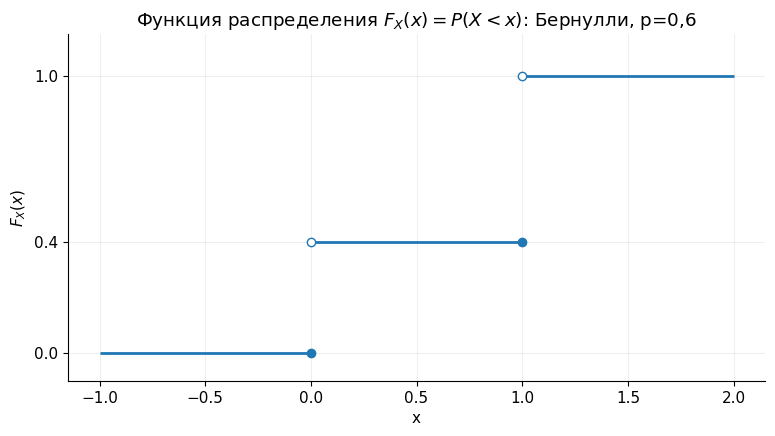

In [5]:
import numpy as np
import matplotlib.pyplot as plt

p1 = 0.6            # P(X=1)
p0 = 1 - p1        # P(X=0) = 0.4

fig, ax = plt.subplots()
# горизонтальные участки F(x) = P(X < x)
ax.hlines(0.0, -1, 0, color="C0", lw=2)
ax.hlines(p0,   0, 1, color="C0", lw=2)   # 0.4
ax.hlines(1.0,  1, 2, color="C0", lw=2)

# закрытые точки: значение включено (F(x)=P(X<x) непрерывна слева)
ax.plot([0, 1], [0.0, p0], "o", color="C0", markersize=6, zorder=3)
# открытые точки: значение не включено
ax.plot([0, 1], [p0, 1.0], "o", color="white",
        markeredgecolor="C0", markersize=6, zorder=3)

ax.set_title("Функция распределения $F_X(x)=P(X<x)$: Бернулли, p=0,6")
ax.set_xlabel("x")
ax.set_ylabel("$F_X(x)$")
ax.set_yticks([0, 0.4, 1.0])
ax.set_ylim(-0.1, 1.15)
plt.show()

### Ответ и пояснения

**Функция распределения:**
$$F_X(x)=\begin{cases}0, & x\le 0,\\[2pt] 0{,}4, & 0<x\le 1,\\[2pt] 1, & x>1.\end{cases}$$

**Пояснение к графику:** ступенчатая функция с двумя скачками. Высота скачка в точке 0 равна $P(X=0)=0{,}4$, в точке 1 — $P(X=1)=0{,}6$; сумма скачков равна 1. Так как используется определение $F_X(x)=P(X<x)$, функция непрерывна слева: в точке скачка левое значение включается (закрашенная точка), правое — нет (белая точка).

---

## Задача 6. Экспоненциальная выборка и теоретическая плотность

**3 балла**

Сгенерируйте 2000 значений из экспоненциального распределения с параметром $\lambda=1{,}5$. Используйте фиксированный seed, указав его в работе. Можно использовать готовые функции NumPy, SciPy и Matplotlib; оцениваются выбор модели, корректность расчётов, графика и статистического вывода, а не синтаксис кода.

1. Постройте нормированную гистограмму с `bins="auto"`.
2. Наложите теоретическую плотность экспоненциального распределения.
3. Добавьте вертикальную линию в точке математического ожидания.
4. Сравните выборочное среднее с теоретическим.

### Решение

Экспоненциальное распределение с параметром $\lambda=1{,}5$ имеет плотность
$$p(x)=\lambda e^{-\lambda x},\quad x\ge 0,$$
и математическое ожидание $\mathrm{E}X = 1/\lambda = 1/1{,}5 \approx 0{,}667$.

В NumPy экспоненциальное распределение задаётся масштабом $\text{scale}=1/\lambda$. Фиксируем seed для воспроизводимости, генерируем 2000 значений, строим нормированную гистограмму (`density=True`, `bins="auto"`), накладываем теоретическую плотность и отмечаем вертикальной линией $\mathrm{E}X$.

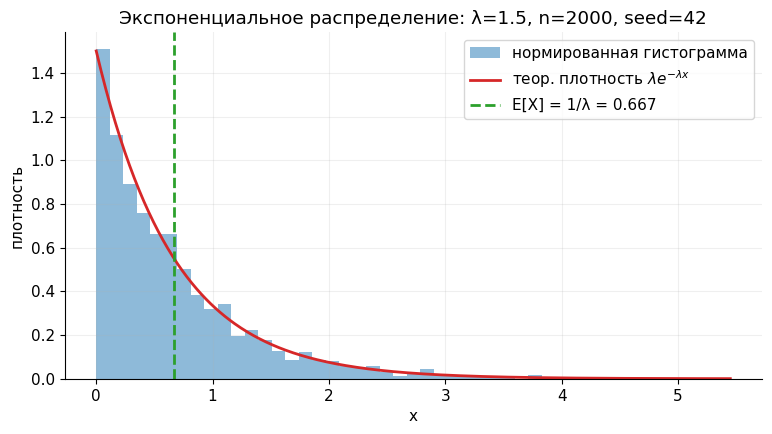

seed:                  42
выборочное среднее:    0.6692
теоретическое 1/λ:     0.6667
абсолютное отклонение: 0.0025


In [6]:
import numpy as np
import matplotlib.pyplot as plt

lam = 1.5
seed = 42
np.random.seed(seed)

x = np.random.exponential(scale=1/lam, size=2000)   # scale = 1/lambda

mean_sample = x.mean()
mean_theor  = 1 / lam

# теоретическая плотность
grid = np.linspace(0, x.max(), 400)
pdf  = lam * np.exp(-lam * grid)

fig, ax = plt.subplots()
ax.hist(x, bins="auto", density=True, alpha=0.5, color="C0",
        label="нормированная гистограмма")
ax.plot(grid, pdf, color="C3", lw=2, label=r"теор. плотность $\lambda e^{-\lambda x}$")
ax.axvline(mean_theor, color="C2", ls="--", lw=2,
           label=f"E[X] = 1/λ = {mean_theor:.3f}")
ax.set_title(f"Экспоненциальное распределение: λ={lam}, n=2000, seed={seed}")
ax.set_xlabel("x")
ax.set_ylabel("плотность")
ax.legend()
plt.show()

print(f"seed:                  {seed}")
print(f"выборочное среднее:    {mean_sample:.4f}")
print(f"теоретическое 1/λ:     {mean_theor:.4f}")
print(f"абсолютное отклонение: {abs(mean_sample - mean_theor):.4f}")

### Ответ и пояснения

**Использованный seed:** 42.

**Выборочное среднее:** $\bar x \approx 0{,}669$.

**Теоретическое среднее:** $\mathrm{E}X = 1/\lambda = 1/1{,}5 \approx 0{,}667$.

**Сравнение и статистический вывод:** выборочное среднее $0{,}669$ практически совпадает с теоретическим $0{,}667$ (отклонение $\approx 0{,}0025$). Форма гистограммы близка к кривой $\lambda e^{-\lambda x}$: максимум плотности у нуля и быстрое убывание. Это согласуется с законом больших чисел — при большом объёме выборки выборочное среднее сходится к $\mathrm{E}X$, а нормированная гистограмма приближает теоретическую плотность.

---

## Задача 7. Выборочная дисперсия и хи-квадрат

**2 балла**

С помощью кода ниже сгенерируйте выборку объёма $n=20$ из распределения $N(0;2^2)$.

1. Вычислите исправленную выборочную дисперсию $s^2$.
2. Укажите число степеней свободы.
3. Вычислите $Q=(n-1)s^2/\sigma^2$.
4. Укажите распределение величины Q.

**Код из условия — запустите без изменения параметров:**

In [7]:
np.random.seed(19)
x = np.random.normal(loc=0, scale=2, size=20)

### Решение

Выборка объёма $n=20$ из $N(0;2^2)$, то есть $\mu=0$, $\sigma=2$, $\sigma^2=4$.

1. Исправленная выборочная дисперсия $s^2=\dfrac{1}{n-1}\sum (x_i-\bar x)^2$ (в коде — `ddof=1`).
2. Число степеней свободы $n-1=19$ (одна степень «уходит» на оценку среднего $\bar x$).
3. $Q=\dfrac{(n-1)s^2}{\sigma^2}$.
4. Для выборки из нормального закона $\dfrac{(n-1)s^2}{\sigma^2}\sim\chi^2_{n-1}$, поэтому $Q$ имеет распределение хи-квадрат с 19 степенями свободы.

In [8]:
import numpy as np

n = 20
sigma2 = 2**2          # дисперсия генеральной совокупности σ² = 4

s2 = x.var(ddof=1)     # исправленная выборочная дисперсия (x задан в ячейке из условия)
df = n - 1
Q  = (n - 1) * s2 / sigma2

print(f"s^2 (ddof=1):           {s2:.4f}")
print(f"число степеней свободы: {df}")
print(f"Q = (n-1)s^2/σ^2:       {Q:.4f}")

s^2 (ddof=1):           2.6213
число степеней свободы: 19
Q = (n-1)s^2/σ^2:       12.4512


### Ответ и пояснения

1. Исправленная выборочная дисперсия: $s^2 \approx 2{,}621$.
2. Число степеней свободы: $n-1 = 19$.
3. Значение $Q = \dfrac{(n-1)s^2}{\sigma^2} = \dfrac{19\cdot 2{,}621}{4} \approx 12{,}45$.
4. Распределение величины $Q$: хи-квадрат с 19 степенями свободы, $Q\sim\chi^2_{19}$ (для выборки из нормального распределения $\frac{(n-1)s^2}{\sigma^2}$ имеет распределение $\chi^2_{n-1}$).

---

## Задача 8. Отношение двух выборочных дисперсий

**2 балла**

Для двух независимых выборок из нормально распределённых совокупностей получены исправленные выборочные дисперсии $s_1^2=2{,}94$ и $s_2^2=1{,}45$. Объёмы выборок равны $n_1=25$ и $n_2=30$. Требуется проверить гипотезу о равенстве генеральных дисперсий.

1. Объясните, для какой цели в этой ситуации используется распределение Фишера.
2. Составьте отношение $F=s_1^2/s_2^2$ и вычислите его.
3. Укажите степени свободы числителя и знаменателя.
4. Объясните, что изменится, если поменять выборки местами в отношении дисперсий.

### Решение

Даны исправленные выборочные дисперсии $s_1^2=2{,}94$ и $s_2^2=1{,}45$ при объёмах $n_1=25$, $n_2=30$. Проверяется гипотеза о равенстве генеральных дисперсий $H_0:\sigma_1^2=\sigma_2^2$.

Если обе выборки взяты из нормальных совокупностей и $H_0$ верна, то отношение исправленных дисперсий
$$F=\frac{s_1^2}{s_2^2}$$
подчиняется распределению Фишера $F(k_1,k_2)$ с $k_1=n_1-1$ и $k_2=n_2-1$ степенями свободы.

$$F=\frac{2{,}94}{1{,}45}\approx 2{,}03,\qquad k_1=24,\quad k_2=29.$$

In [9]:
s1_2, s2_2 = 2.94, 1.45
n1, n2 = 25, 30

F = s1_2 / s2_2
df1, df2 = n1 - 1, n2 - 1

print(f"F = s1^2/s2^2 = {s1_2}/{s2_2} = {F:.4f}")
print(f"степени свободы: числитель {df1}, знаменатель {df2}")
print(f"обратное отношение s2^2/s1^2 = {1/F:.4f} со степенями ({df2}, {df1})")

F = s1^2/s2^2 = 2.94/1.45 = 2.0276
степени свободы: числитель 24, знаменатель 29
обратное отношение s2^2/s1^2 = 0.4932 со степенями (29, 24)


### Ответ и пояснения

1. Для чего используется распределение Фишера: для проверки гипотезы о равенстве дисперсий двух нормальных совокупностей ($H_0:\sigma_1^2=\sigma_2^2$). При верной $H_0$ отношение исправленных выборочных дисперсий имеет распределение Фишера, с критическими точками которого и сравнивают наблюдаемое $F$.
2. Отношение дисперсий: $F = s_1^2/s_2^2 = 2{,}94/1{,}45 \approx 2{,}03$.
3. Степени свободы: числителя $k_1 = n_1-1 = 24$, знаменателя $k_2 = n_2-1 = 29$.
4. Что изменится при перестановке: получится обратная величина $F' = s_2^2/s_1^2 = 1/2{,}03 \approx 0{,}49$, а степени свободы поменяются местами — станут $(29, 24)$. Содержательный вывод не меняется. Обычно в числитель ставят большую дисперсию, чтобы получить $F\ge 1$ и сравнивать с правосторонней критической точкой.

---

## Проверьте перед сдачей

- [ ] Заполнены фамилия, имя и группа.
- [ ] Выполнены все 8 задач и все пункты условий.
- [ ] В работе есть расчёты и пояснения, а не только итоговые числа.
- [ ] В задачах 5 и 6 сохранены графики; в задаче 6 указан seed.
- [ ] Код запускается последовательно сверху вниз без ошибок; результаты и графики сохранены.
- [ ] Подсказки-заготовки заменены собственным решением.
- [ ] Заполненный ноутбук скачан в формате `.ipynb`.
- [ ] К форме сдачи на платформе прикреплён скачанный `.ipynb`-файл.

### Формат сдачи работы

После выполнения заданий скачайте заполненный ноутбук в формате `.ipynb` и прикрепите этот файл к форме сдачи работы на платформе.

К сдаче принимается только заполненный ноутбук, содержащий выполненные задания, расчёты, код, графики и пояснения к ответам.